In [1]:
!pip install numpy matplotlib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

--- MATRICE DE CONFUSION ---
[[11  0]
 [ 0  9]]


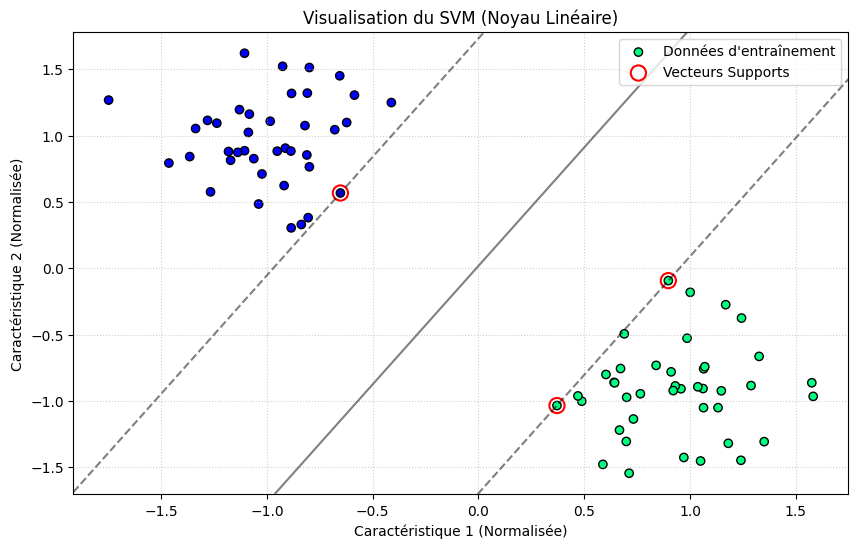

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ==========================================
# 1. Génération de données fictives (2 classes)
# ==========================================
# On crée 100 points avec 2 caractéristiques (features)
X, y = datasets.make_blobs(
    n_samples=100, n_features=2, centers=2, random_state=42, cluster_std=1.2
)

# ==========================================
# 2. Division et Normalisation des données
# ==========================================
# Séparation en données d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Les SVM sont sensibles à l'échelle des données, on les normalise
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 3. Création et Entraînement du modèle SVM
# ==========================================
# Utilisation d'un noyau (kernel) linéaire
model_svm = SVC(kernel="linear", C=1.0)
model_svm.fit(X_train, y_train)

# ==========================================
# 4. Évaluation du modèle
# ==========================================
y_pred = model_svm.predict(X_test)

print("--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred))

print("--- MATRICE DE CONFUSION ---")
print(confusion_matrix(y_test, y_pred))

# ==========================================
# 5. Visualisation de la frontière de décision
# ==========================================
plt.figure(figsize=(10, 6))

# Affichage des points d'entraînement
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap="winter",
    edgecolors="k",
    label="Données d'entraînement",
)

# Récupération des limites du graphique pour tracer la grille
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Création de la grille de points
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Calcul de la fonction de décision pour tracer l'hyperplan
Z = model_svm.decision_function(xy).reshape(XX.shape)

# Tracer l'hyperplan (ligne continue) et les marges (lignes pointillées)
ax.contour(
    XX,
    YY,
    Z,
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.5,
    linestyles=["--", "-", "--"],
)

# Mettre en valeur les vecteurs supports (entourés en rouge)
ax.scatter(
    model_svm.support_vectors_[:, 0],
    model_svm.support_vectors_[:, 1],
    s=120,
    linewidth=1.5,
    facecolors="none",
    edgecolors="r",
    label="Vecteurs Supports",
)

plt.title("Visualisation du SVM (Noyau Linéaire)")
plt.xlabel("Caractéristique 1 (Normalisée)")
plt.ylabel("Caractéristique 2 (Normalisée)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

In [5]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


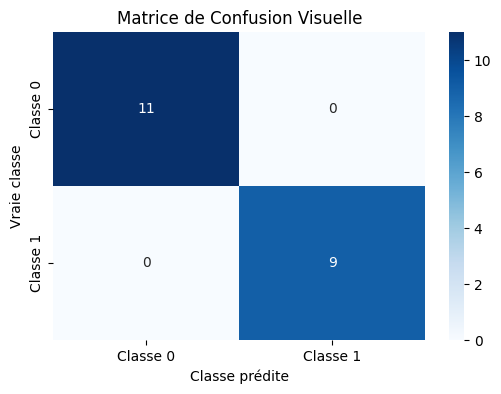

In [6]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.title('Matrice de Confusion Visuelle')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.show()

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



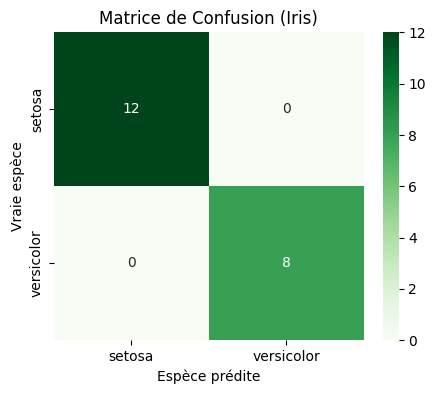

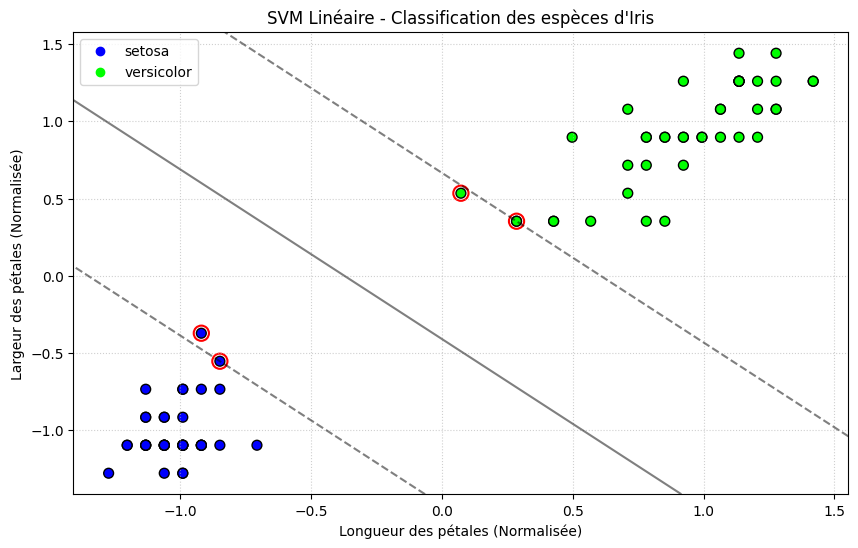

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn import datasets
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ==========================================
# 1. Chargement du vrai Dataset (Iris)
# ==========================================
iris = datasets.load_iris()

# Pour la classification binaire et la visualisation en 2D :
# On ne garde que les deux premières classes (Setosa et Versicolor)
# Et on prend les deux caractéristiques des pétales (longueur et largeur)
bi_class_mask = iris.target < 2
X = iris.data[bi_class_mask][:, 2:]  # Longueur et largeur des pétales
y = iris.target[bi_class_mask]

class_names = [iris.target_names[0], iris.target_names[1]]

# ==========================================
# 2. Division et Normalisation des données
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 3. Création et Entraînement du modèle SVM
# ==========================================
model_svm = SVC(kernel="linear", C=1.0)
model_svm.fit(X_train, y_train)

# ==========================================
# 4. Évaluation du modèle
# ==========================================
y_pred = model_svm.predict(X_test)

print("--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Affichage de la matrice de confusion avec Seaborn
plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Matrice de Confusion (Iris)")
plt.ylabel("Vraie espèce")
plt.xlabel("Espèce prédite")
plt.show()

# ==========================================
# 5. Visualisation de la frontière de décision
# ==========================================
plt.figure(figsize=(10, 6))

# Affichage des points d'entraînement (Setosa en bleu, Versicolor en vert)
scatter = plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap="brg",
    edgecolors="k",
    s=50,
)

# Configuration de la légende pour les classes
handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    class_names + ["Vecteurs Supports"],
    loc="upper left",
)

# Récupération des limites du graphique
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Création de la grille pour tracer l'hyperplan
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model_svm.decision_function(xy).reshape(XX.shape)

# Tracer l'hyperplan de décision et les marges
ax.contour(
    XX,
    YY,
    Z,
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.5,
    linestyles=["--", "-", "--"],
)

# Mettre en valeur les vecteurs supports entourés en rouge
ax.scatter(
    model_svm.support_vectors_[:, 0],
    model_svm.support_vectors_[:, 1],
    s=120,
    linewidth=1.5,
    facecolors="none",
    edgecolors="r",
)

plt.title("SVM Linéaire - Classification des espèces d'Iris")
plt.xlabel("Longueur des pétales (Normalisée)")
plt.ylabel("Largeur des pétales (Normalisée)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

Nombre d'images dans le dataset : 1797
Nombre de pixels par image : 64 (8x8 pixels)

--- RAPPORT DE CLASSIFICATION (0 à 9) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



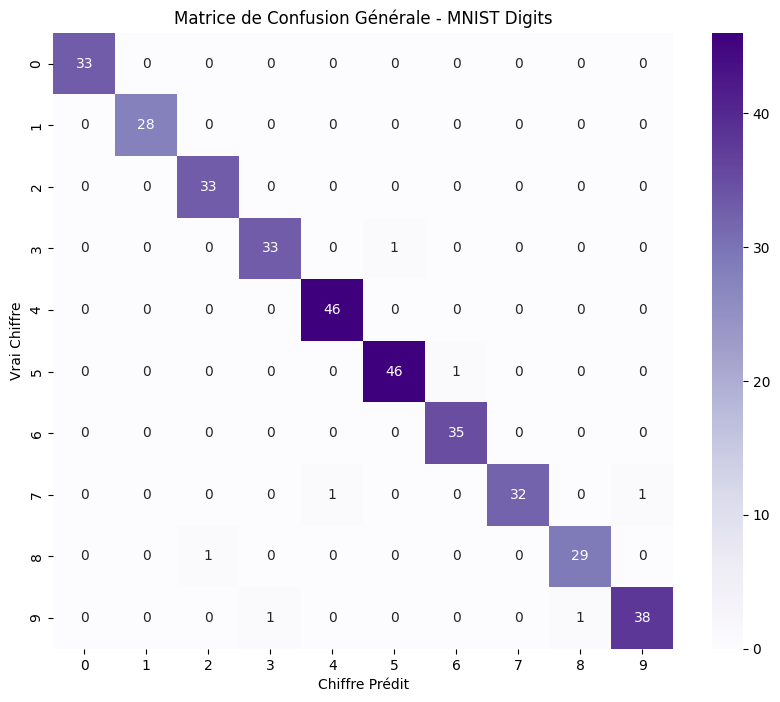

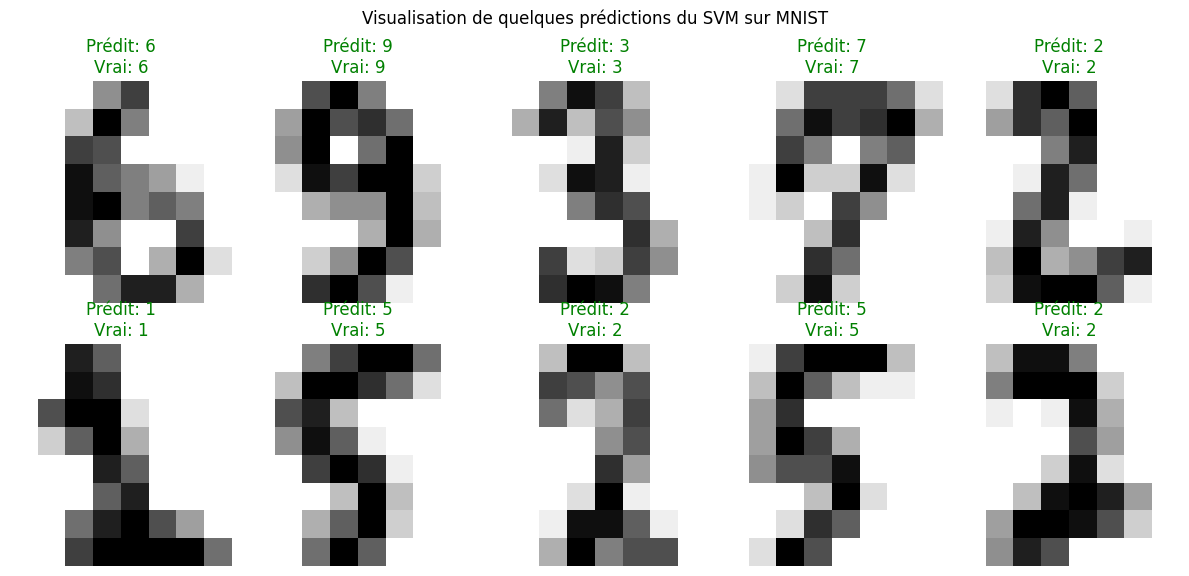

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn import datasets
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ==========================================
# 1. Chargement du Dataset MNIST (Digits)
# ==========================================
# Chaque image est un tableau de 8x8 pixels (64 caractéristiques)
digits = datasets.load_digits()
X = digits.data
y = digits.target

print(f"Nombre d'images dans le dataset : {X.shape[0]}")
print(f"Nombre de pixels par image : {X.shape[1]} (8x8 pixels)")

# ==========================================
# 2. Division et Normalisation des données
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# La normalisation est essentielle car les pixels vont de 0 à 16
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 3. Création et Entraînement du modèle SVM
# ==========================================
# Pour MNIST, le noyau linéaire fonctionne bien, mais le noyau 'rbf' est souvent plus performant
model_svm = SVC(kernel="rbf", C=5.0, gamma="scale")
model_svm.fit(X_train, y_train)

# ==========================================
# 4. Évaluation globale du modèle
# ==========================================
y_pred = model_svm.predict(X_test)

print("\n--- RAPPORT DE CLASSIFICATION (0 à 9) ---")
print(classification_report(y_test, y_pred))

# Affichage de la matrice de confusion globale (10x10)
plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=digits.target_names,
    yticklabels=digits.target_names,
)
plt.title("Matrice de Confusion Générale - MNIST Digits")
plt.ylabel("Vrai Chiffre")
plt.xlabel("Chiffre Prédit")
plt.show()

# ==========================================
# 5. Visualisation des prédictions du SVM
# ==========================================
# On reprend les images de test non-normalisées pour l'affichage visuel
_, X_test_images, _, _ = train_test_split(
    digits.images, y, test_size=0.2, random_state=42
)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_images[i], cmap=plt.cm.gray_r, interpolation="nearest")

    # Couleur du titre : vert si la prédiction est bonne, rouge si erreur
    color = "green" if y_pred[i] == y_test[i] else "red"
    plt.title(f"Prédit: {y_pred[i]}\nVrai: {y_test[i]}", color=color)
    plt.axis("off")

plt.suptitle("Visualisation de quelques prédictions du SVM sur MNIST")
plt.tight_layout()
plt.show()

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

      Tomate       1.00      1.00      1.00        12
      Orange       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



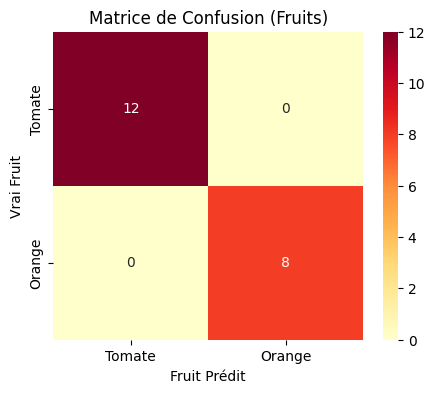

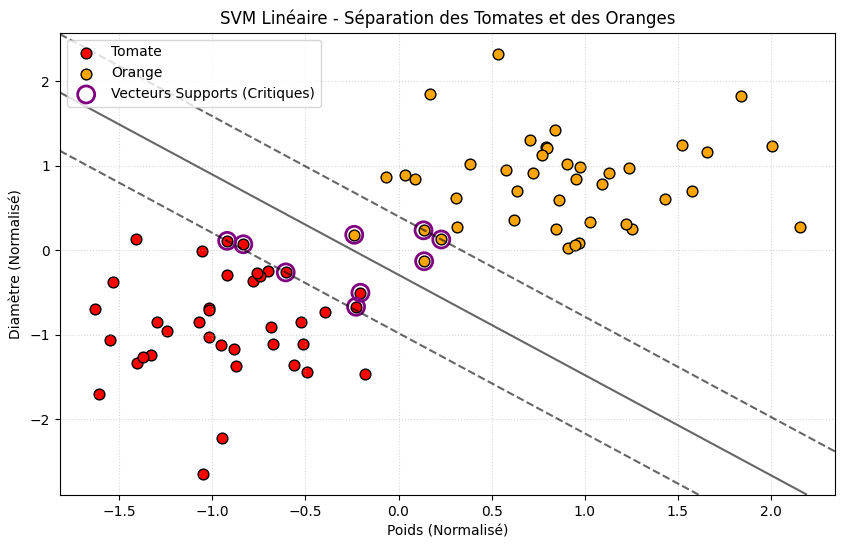

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ==========================================
# 1. Création du Dataset : Tomates vs Oranges
# ==========================================
np.random.seed(42)

# Classe 0 : Tomates (Plus légères, plus petites)
# Poids moyen : 120g, Diamètre moyen : 6cm
poids_tomates = np.random.normal(120, 15, 50)
diametre_tomates = np.random.normal(6, 0.8, 50)
X_tomates = np.vstack((poids_tomates, diametre_tomates)).T
y_tomates = np.zeros(50)  # Label 0 pour Tomate

# Classe 1 : Oranges (Plus lourdes, plus grandes)
# Poids moyen : 180g, Diamètre moyen : 8cm
poids_oranges = np.random.normal(180, 20, 50)
diametre_oranges = np.random.normal(8, 0.7, 50)
X_oranges = np.vstack((poids_oranges, diametre_oranges)).T
y_oranges = np.ones(50)  # Label 1 pour Orange

# Fusion des données
X = np.vstack((X_tomates, X_oranges))
y = np.concatenate((y_tomates, y_oranges))
class_names = ["Tomate", "Orange"]

# ==========================================
# 2. Division et Normalisation des données
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 3. Création et Entraînement du modèle SVM
# ==========================================
model_svm = SVC(kernel="linear", C=1.0)
model_svm.fit(X_train, y_train)

# ==========================================
# 4. Évaluation du modèle
# ==========================================
y_pred = model_svm.predict(X_test)

print("--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Matrice de confusion customisée (Orange et Rouge !)
plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Matrice de Confusion (Fruits)")
plt.ylabel("Vrai Fruit")
plt.xlabel("Fruit Prédit")
plt.show()

# ==========================================
# 5. Visualisation : Séparation des Tomates et Oranges
# ==========================================
plt.figure(figsize=(10, 6))

# On trace les Tomates en Rouge et les Oranges en Orange
for i, color, label in zip([0, 1], ["red", "orange"], class_names):
    plt.scatter(
        X_train[y_train == i, 0],
        X_train[y_train == i, 1],
        color=color,
        label=label,
        edgecolors="k",
        s=60,
    )

# Récupération des limites du graphique
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Création de la grille pour l'hyperplan
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model_svm.decision_function(xy).reshape(XX.shape)

# Tracer l'hyperplan de décision et les marges
ax.contour(
    XX,
    YY,
    Z,
    colors="black",
    levels=[-1, 0, 1],
    alpha=0.6,
    linestyles=["--", "-", "--"],
)

# Mettre en valeur les vecteurs supports (entourés en noir épais ou violet)
ax.scatter(
    model_svm.support_vectors_[:, 0],
    model_svm.support_vectors_[:, 1],
    s=150,
    linewidth=2,
    facecolors="none",
    edgecolors="purple",
    label="Vecteurs Supports (Critiques)",
)

plt.title("SVM Linéaire - Séparation des Tomates et des Oranges")
plt.xlabel("Poids (Normalisé)")
plt.ylabel("Diamètre (Normalisé)")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()